In [ ]:
!pip install kaggle

In [1]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"blossomspine","key":"9ab6979c60c7e62d7a3b8d19a212f189"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d vuppalaadithyasairam/ultrasound-breast-images-for-breast-cancer -p ./data --unzip

Dataset URL: https://www.kaggle.com/datasets/vuppalaadithyasairam/ultrasound-breast-images-for-breast-cancer
License(s): CC0-1.0
 92% 522M/564M [00:07<00:00, 76.0MB/s]
100% 564M/564M [00:07<00:00, 79.7MB/s]


In [ ]:
import os
import shutil
import random

# Paths
DATASET_PATH = "/content/data/ultrasound breast classification/train"   # adjust if different
OUTPUT_PATH = "/content/data/ultrasound breast classification/train/train1"

# Classes in dataset
classes = ["benign","malignant"]

# Make sure output train folder exists
os.makedirs(OUTPUT_PATH, exist_ok=True)

# Process each class
for cls in classes:
    src_folder = os.path.join(DATASET_PATH, cls)
    dst_folder = os.path.join(OUTPUT_PATH, cls.replace(" ", "_"))  # replace spaces with underscore
    os.makedirs(dst_folder, exist_ok=True)

    # Get list of images
    images = [f for f in os.listdir(src_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    # Shuffle to randomize
    random.shuffle(images)

    # Take images
    selected_images = images[:1500]

    # Copy to train folder
    for img in selected_images:
        shutil.copy(os.path.join(src_folder, img), os.path.join(dst_folder, img))

    print(f"{cls}: {len(selected_images)} images copied to {dst_folder}")

print(" Train dataset prepared successfully!")

benign: 1500 images copied to /content/data/ultrasound breast classification/train/train1/benign
malignant: 1500 images copied to /content/data/ultrasound breast classification/train/train1/malignant
 Train dataset prepared successfully!


In [ ]:
train_dir = "/content/data/ultrasound breast classification/train/train1"

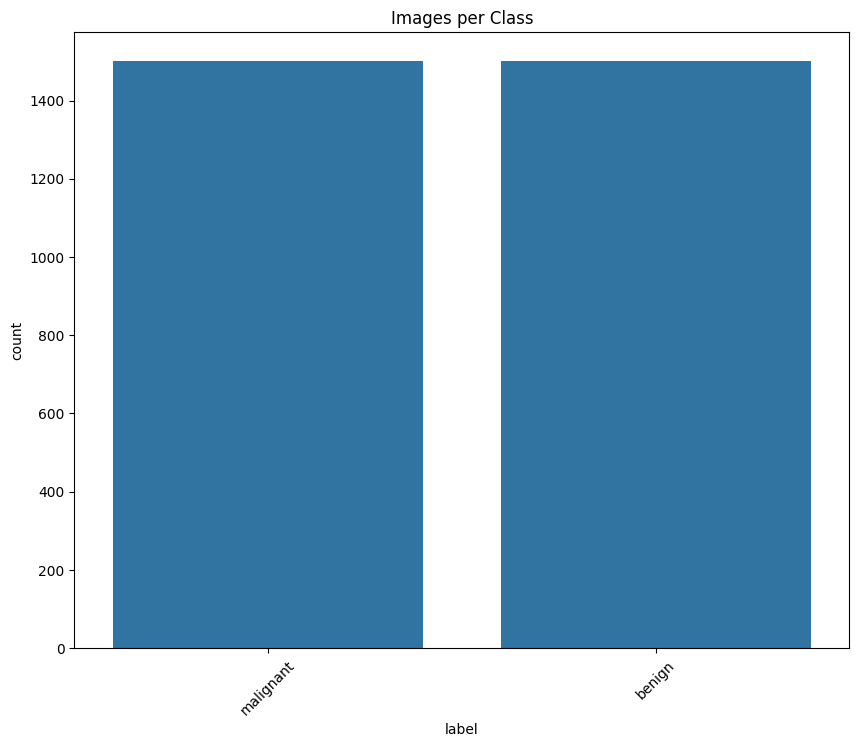

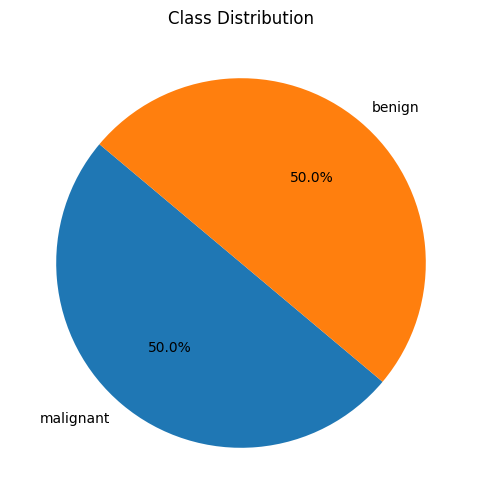

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Count images per class
df = pd.DataFrame([(cls, len(os.listdir(os.path.join(train_dir, cls))))
                   for cls in os.listdir(train_dir)], columns=["label", "count"])

# Bar chart
plt.figure(figsize=(10, 8))
sns.barplot(x="label", y="count", data=df)
plt.xticks(rotation=45)
plt.title("Images per Class")
plt.show()

# Pie chart
df.set_index("label")["count"].plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=140,
    figsize=(6, 6),
)
plt.title("Class Distribution")
plt.ylabel("")
plt.show()

In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# Build DataFrame with filepaths and labels
df_balanced = pd.DataFrame()
for i, cls in enumerate(os.listdir(train_dir)):
    cls_path = os.path.join(train_dir, cls)
    images = os.listdir(cls_path)
    df_cls = pd.DataFrame({
        "filepath": [os.path.join(cls_path, img) for img in images],
        "label": cls,
        "label_num": str(i)  # numeric label as string
    })
    df_balanced = pd.concat([df_balanced, df_cls], ignore_index=True)

# Train (80%), temp (20%)
train_df, temp_df = train_test_split(
    df_balanced,
    train_size=0.8,
    shuffle=True,
    stratify=df_balanced['label_num'],
    random_state=42
)

# Validation (10%), Test (10%)
valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    shuffle=True,
    stratify=temp_df['label_num'],
    random_state=42
)

# Check sizes
print("Train size:", train_df.shape)
print("Validation size:", valid_df.shape)
print("Test size:", test_df.shape)

# Class balance check
print("\nTrain class distribution:\n", train_df['label_num'].value_counts())
print("\nValidation class distribution:\n", valid_df['label_num'].value_counts())
print("\nTest class distribution:\n", test_df['label_num'].value_counts())

Train size: (2400, 3)
Validation size: (300, 3)
Test size: (300, 3)

Train class distribution:
 label_num
1    1200
0    1200
Name: count, dtype: int64

Validation class distribution:
 label_num
1    150
0    150
Name: count, dtype: int64

Test class distribution:
 label_num
1    150
0    150
Name: count, dtype: int64


You already have a stratified validation set so no further need to use cross validation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

batch_size = 32
img_size = (224, 224)

tr_gen = ImageDataGenerator(
   preprocessing_function=preprocess_input,
    rotation_range=15,           # small rotations only
    width_shift_range=0.05,      # slight horizontal shifts
    height_shift_range=0.05,     # slight vertical shifts
    zoom_range=0.1,              # mild zoom
    horizontal_flip=True,        # flipping is okay for US images
    vertical_flip=False,         # usually vertical flip is not applied in US images
    shear_range=0.05,            # small shear
    fill_mode='nearest'          # fill empty pixels
    )

ts_gen = ImageDataGenerator(preprocessing_function=preprocess_input)


train_gen = tr_gen.flow_from_dataframe(train_df, x_col='filepath', y_col='label_num',
                                       target_size=img_size, class_mode='sparse',
                                       color_mode='rgb', shuffle=True, batch_size=batch_size)

valid_gen = ts_gen.flow_from_dataframe(valid_df, x_col='filepath', y_col='label_num',
                                       target_size=img_size, class_mode='sparse',
                                       color_mode='rgb', shuffle=True, batch_size=batch_size)

test_gen = ts_gen.flow_from_dataframe(test_df, x_col='filepath', y_col='label_num',
                                      target_size=img_size, class_mode='sparse',
                                      color_mode='rgb', shuffle=False, batch_size=batch_size)


Found 2400 validated image filenames belonging to 2 classes.
Found 300 validated image filenames belonging to 2 classes.
Found 300 validated image filenames belonging to 2 classes.


In [ ]:

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D, Multiply, Reshape, Activation, GlobalAveragePooling2D, Conv2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K
from tensorflow.keras.layers import Layer
import tensorflow as tf

# Define SE Block
def se_block(input_tensor, reduction=16):
    channels = input_tensor.shape[-1]
    se = GlobalAveragePooling2D()(input_tensor)
    se = Reshape((1,1,channels))(se)
    se = Dense(channels // reduction, activation='relu', kernel_initializer='he_normal', use_bias=False)(se)
    se = Dense(channels, activation='sigmoid', kernel_initializer='he_normal', use_bias=False)(se)
    return Multiply()([input_tensor, se])

# EfficientNet with SE
def create_efficientnet_senet(input_shape=(224,224,3), num_classes=2):
    inputs = Input(shape=input_shape)
    base = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=inputs)

    # Freeze most layers
    for layer in base.layers[:-10]:
        layer.trainable = False

    x = base.output

    # Apply SE block
    x = se_block(x)

    # Global pooling and dense layers
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)

# Create and compile the SE-EfficientNet model
model = create_efficientnet_senet(num_classes=2)
model.compile(optimizer=Adam(0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 5,044,133 (19.24 MB)

 Trainable params: 1,886,770 (7.20 MB)

 Non-trainable params: 3,157,363 (12.04 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint , ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint("best_model.h5", monitor='val_accuracy', save_best_only=True, verbose=1)
]

history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=20,
    callbacks= callbacks,
    verbose=1
)

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6470 - loss: 0.8663
Epoch 1: val_accuracy improved from -inf to 0.82000, saving model to best_model.h5


75/75 ━━━━━━━━━━━━━━━━━━━━ 278s 3s/step - accuracy: 0.6480 - loss: 0.8638 - val_accuracy: 0.8200 - val_loss: 0.5735 - learning_rate: 1.0000e-04
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8082 - loss: 0.4521
Epoch 2: val_accuracy improved from 0.82000 to 0.87667, saving model to best_model.h5


75/75 ━━━━━━━━━━━━━━━━━━━━ 265s 4s/step - accuracy: 0.8081 - loss: 0.4520 - val_accuracy: 0.8767 - val_loss: 0.4744 - learning_rate: 1.0000e-04
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8465 - loss: 0.3663
Epoch 3: val_accuracy improved from 0.87667 to 0.90667, saving model to best_model.h5


75/75 ━━━━━━━━━━━━━━━━━━━━ 259s 3s/step - accuracy: 0.8465 - loss: 0.3664 - val_accuracy: 0.9067 - val_loss: 0.3858 - learning_rate: 1.0000e-04
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8464 - loss: 0.3526
Epoch 4: val_accuracy improved from 0.90667 to 0.91000, saving model to best_model.h5


75/75 ━━━━━━━━━━━━━━━━━━━━ 255s 3s/step - accuracy: 0.8467 - loss: 0.3520 - val_accuracy: 0.9100 - val_loss: 0.2990 - learning_rate: 1.0000e-04
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8802 - loss: 0.2817
Epoch 5: val_accuracy improved from 0.91000 to 0.93333, saving model to best_model.h5


75/75 ━━━━━━━━━━━━━━━━━━━━ 262s 4s/step - accuracy: 0.8803 - loss: 0.2815 - val_accuracy: 0.9333 - val_loss: 0.2396 - learning_rate: 1.0000e-04
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8903 - loss: 0.2624
Epoch 6: val_accuracy did not improve from 0.93333
75/75 ━━━━━━━━━━━━━━━━━━━━ 252s 3s/step - accuracy: 0.8904 - loss: 0.2622 - val_accuracy: 0.9200 - val_loss: 0.2110 - learning_rate: 1.0000e-04
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9166 - loss: 0.2077
Epoch 7: val_accuracy did not improve from 0.93333
75/75 ━━━━━━━━━━━━━━━━━━━━ 274s 4s/step - accuracy: 0.9166 - loss: 0.2076 - val_accuracy: 0.9233 - val_loss: 0.1924 - learning_rate: 1.0000e-04
Epoch 8/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9127 - loss: 0.1792
Epoch 8: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 8: val_accuracy did not improve from 0.93333
75/75 ━━━━━━━━━━━━━━━━━━━━ 255s 3s/step - accuracy: 0.9127 - loss: 0.1794 - val_accuracy:

75/75 ━━━━━━━━━━━━━━━━━━━━ 255s 3s/step - accuracy: 0.9297 - loss: 0.1753 - val_accuracy: 0.9400 - val_loss: 0.1743 - learning_rate: 5.0000e-05
Epoch 12/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9423 - loss: 0.1407
Epoch 12: val_accuracy did not improve from 0.94000
75/75 ━━━━━━━━━━━━━━━━━━━━ 271s 4s/step - accuracy: 0.9423 - loss: 0.1407 - val_accuracy: 0.9267 - val_loss: 0.1660 - learning_rate: 5.0000e-05
Epoch 13/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9404 - loss: 0.1497
Epoch 13: val_accuracy did not improve from 0.94000
75/75 ━━━━━━━━━━━━━━━━━━━━ 236s 3s/step - accuracy: 0.9404 - loss: 0.1497 - val_accuracy: 0.9400 - val_loss: 0.1454 - learning_rate: 5.0000e-05
Epoch 14/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9489 - loss: 0.1311
Epoch 14: val_accuracy improved from 0.94000 to 0.94333, saving model to best_model.h5


75/75 ━━━━━━━━━━━━━━━━━━━━ 246s 3s/step - accuracy: 0.9488 - loss: 0.1312 - val_accuracy: 0.9433 - val_loss: 0.1499 - learning_rate: 5.0000e-05
Epoch 15/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9507 - loss: 0.1317
Epoch 15: val_accuracy improved from 0.94333 to 0.95333, saving model to best_model.h5


75/75 ━━━━━━━━━━━━━━━━━━━━ 258s 3s/step - accuracy: 0.9506 - loss: 0.1318 - val_accuracy: 0.9533 - val_loss: 0.1444 - learning_rate: 5.0000e-05
Epoch 16/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9333 - loss: 0.1602
Epoch 16: val_accuracy did not improve from 0.95333
75/75 ━━━━━━━━━━━━━━━━━━━━ 241s 3s/step - accuracy: 0.9334 - loss: 0.1599 - val_accuracy: 0.9467 - val_loss: 0.1433 - learning_rate: 5.0000e-05
Epoch 17/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9592 - loss: 0.1102
Epoch 17: val_accuracy did not improve from 0.95333
75/75 ━━━━━━━━━━━━━━━━━━━━ 274s 4s/step - accuracy: 0.9591 - loss: 0.1104 - val_accuracy: 0.9500 - val_loss: 0.1476 - learning_rate: 5.0000e-05
Epoch 18/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9554 - loss: 0.1076
Epoch 18: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.

Epoch 18: val_accuracy did not improve from 0.95333
75/75 ━━━━━━━━━━━━━━━━━━━━ 255s 3s/step - accuracy: 0.9554 - loss: 0.1077 - val_ac

In [ ]:
loss, accuracy = model.evaluate(test_gen, verbose=1)

print(f"Final Test Accuracy: {accuracy*100:.2f}%")
print(f"Final Test Loss: {loss:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.9418 - loss: 0.1372
Final Test Accuracy: 95.33%
Final Test Loss: 0.1163


In [ ]:
from tensorflow.keras.models import load_model
best_model = load_model('best_model.h5')

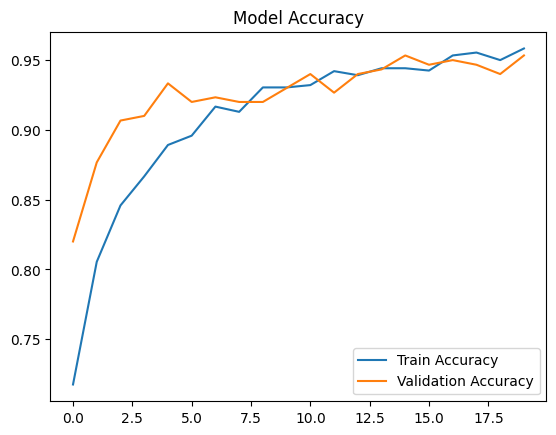

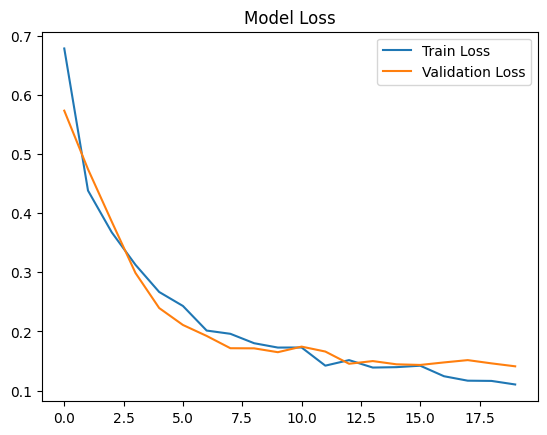

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Model Loss")
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       150
           1       0.97      0.94      0.95       150

    accuracy                           0.95       300
   macro avg       0.95      0.95      0.95       300
weighted avg       0.95      0.95      0.95       300



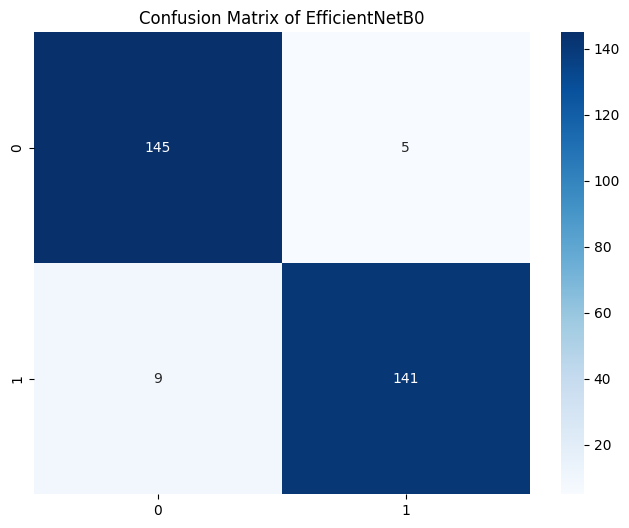

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# True labels from test generator
y_true = test_gen.classes

# Predictions
y_pred = np.argmax(model.predict(test_gen), axis=1) #argmax finds the index of the largest value in an array

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=list(test_gen.class_indices.keys())))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_gen.class_indices.keys(),
            yticklabels=test_gen.class_indices.keys())
plt.title("Confusion Matrix of EfficientNetB0")
plt.show()


Grad-CAM for class 1: /content/data/ultrasound breast classification/train/train1/benign/benign (95)-sharpened-rotated2.png


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_1']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


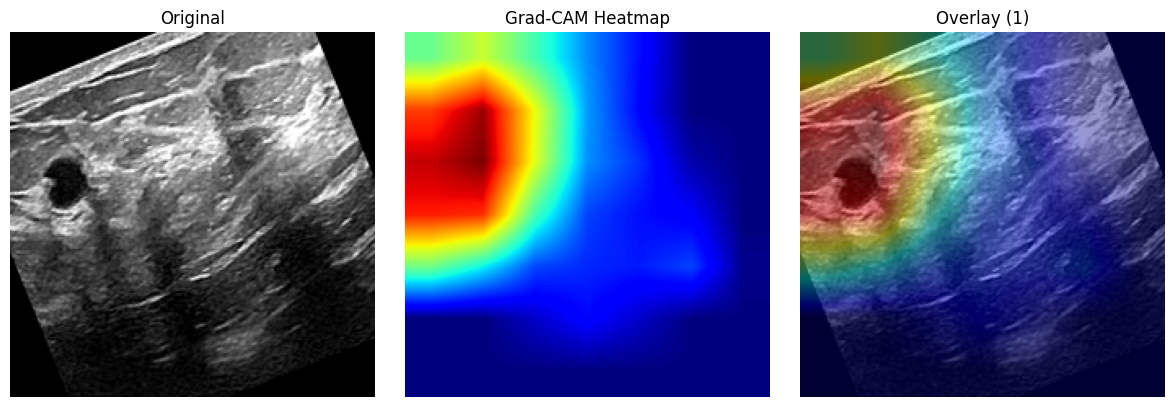

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predicted class id: 1 | Probability: 1.000
True class: 1

Grad-CAM for class 0: /content/data/ultrasound breast classification/train/train1/malignant/malignant (119)-rotated1-rotated32.png


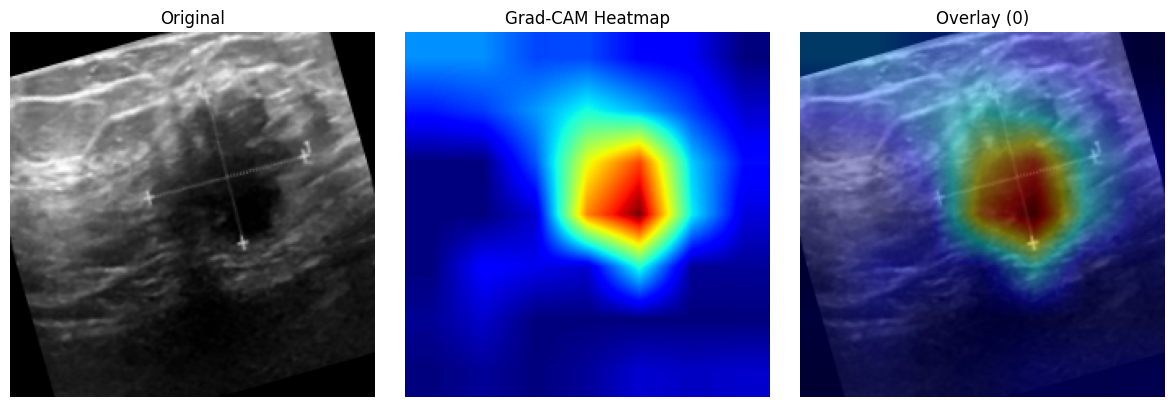

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
Predicted class id: 0 | Probability: 0.999
True class: 0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
import cv2

# ---------- Grad-CAM function ----------
def make_gradcam_heatmap(img_array, model, last_conv_layer_name="top_conv", pred_index=None):
    """
    Generates Grad-CAM heatmap for a single image.
    """
    # Model: input -> last conv layer + output
    grad_model = Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

# ---------- Display function ----------
def display_gradcam(img_path, model, class_name=None, last_conv_layer_name="top_conv", alpha=0.4):
    """
    Load image, generate Grad-CAM, display original, heatmap, and overlay.
    """
    img_size = (224,224)
    # Load & preprocess
    img = tf.keras.utils.load_img(img_path, target_size=img_size)
    img_array = tf.keras.utils.img_to_array(img)
    img_array_exp = np.expand_dims(img_array, axis=0)
    img_array_exp = tf.keras.applications.efficientnet.preprocess_input(img_array_exp)

    # Grad-CAM
    heatmap = make_gradcam_heatmap(img_array_exp, model, last_conv_layer_name)

    # Resize and overlay
    heatmap_resized = cv2.resize(heatmap, img_size)
    heatmap_uint8 = np.uint8(255*heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

    original_img = cv2.imread(img_path)
    original_img = cv2.resize(original_img, img_size)

    overlay_img = cv2.addWeighted(original_img, 1-alpha, heatmap_color, alpha, 0)

    # Plot
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(heatmap_resized, cmap="jet")
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(cv2.cvtColor(overlay_img, cv2.COLOR_BGR2RGB))
    title_str = "Overlay"
    if class_name:
        title_str += f" ({class_name})"
    plt.title(title_str)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # Prediction info
    preds = model.predict(img_array_exp)
    pred_idx = np.argmax(preds)
    pred_prob = preds[0][pred_idx]
    print(f"Predicted class id: {pred_idx} | Probability: {pred_prob:.3f}")
    if class_name:
        print(f"True class: {class_name}")

# ---------- Pick one sample image per class ----------
class_ids = test_df['label_num'].unique()
sample_imgs = []
for cls in class_ids:
    img_path = test_df[test_df['label_num']==cls]['filepath'].iloc[0]
    sample_imgs.append((img_path, cls))

# ---------- Display Grad-CAM for each class ----------
for img_path, cls in sample_imgs:
    class_name = str(cls)  # optionally map to actual class names
    print(f"\nGrad-CAM for class {cls}: {img_path}")
    display_gradcam(img_path, best_model, class_name=class_name, last_conv_layer_name="top_conv")